In [107]:
!pip install python-dotenv langchain langchain-core langchain-community langchain-google-genai chromadb langchain-text-splitters beautifulsoup4 sentence-transformers einops langchainhub langsmith faiss-cpu pydantic rank_bm25 sentence-transformers 
!pip install langchain-google-vertexai

In [108]:
# !curl "https://aiplatform.googleapis.com/v1/publishers/google/models/gemini-3-flash-preview:streamGenerateContent?key=AQ.Ab8RN6KRw3jXG5kRUuBmsznpQwBfAKRXGyorHhDhg_c7TmxCwQ" -X POST -H "Content-Type: application/json" -d '{"contents":[{"role":"user","parts":[{"text":"Explain how AI works in a few words"}]}]}'

# In terminal google cloud vertex ai setup
# !curl https://sdk.cloud.google.com | bash
# ! gcloud auth application-default login

## Declaration

In [109]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
import transformers
import json
import numpy as np
import os
import warnings
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import List
from langchain_community.retrievers import BM25Retriever
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from typing import TypedDict, List
from sentence_transformers import CrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import time


load_dotenv()
google_api_key = os.getenv("GOOGLE_API_KEY")
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
warnings.filterwarnings("ignore")



class QueryOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class QueryOptimizerOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class GraphState(TypedDict):
    query: str
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str
    documents: List[Document]
    answer: str
    iteration: int
    retrieval_feedback: dict
    doc_scores: List[float]


### Models

In [110]:
llm_compression = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)
# llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

structured_llm = llm.with_structured_output(QueryOutput)
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
embeddings = HuggingFaceEmbeddings(model_name="nomic-ai/nomic-embed-text-v1",model_kwargs={"trust_remote_code": True})


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7897.18it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
<All keys matched successfully>


In [111]:
import random

def safe_llm_invoke(llm, prompt, retries=5):
    last_error = None

    for i in range(retries):
        try:
            return llm.invoke(prompt)
        except Exception as e:
            last_error = e
            wait_time = (2 ** i) + random.uniform(0, 1)
            print(f"[Retry {i+1}] Waiting {wait_time:.2f}s →", repr(e))
            time.sleep(wait_time)

    raise last_error

## Query Rewritting & Expansion

* User Query  ->  Query Rewriting  ->  Step-Back Query  ->  Query Expansion


| Step      | Why                                      |
| --------- | ---------------------------------------- |
| Rewrite   | cleans the query and removes ambiguity   |
| Step-back | captures **higher-level concept**        |
| Expansion | generates **multiple search variations** |


In [112]:
optimizer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert query optimizer. Return ONLY JSON."),
    ("human", """
        User Query:
        {query}

        Perform:
        1. Rewrite query
        2. Generate 3 variations
        3. Generate step-back query

        Return JSON:

        {{
        "rewritten_query": "...",
        "expanded_queries": ["...", "...", "...", "..."],
        "step_back_query": "..."
        }}
    """)
])

def query_intelligence_node(state):

    iteration = state.get("iteration", 0)

    # PASS 1 (normal)
    if iteration == 0:
        query = state["query"]

        prompt = optimizer_prompt.invoke({
            "query": query
        })

    # PASS 2 (feedback-driven)
    else:
        feedback = state.get("retrieval_feedback", {})

        snippets = [
            doc.page_content[:200] 
            for doc in state.get("documents", [])[:2]
        ]

        refined_query = f"""
            Previous retrieval failed.

            Reason: {feedback.get("reason")}
            Max Score: {feedback.get("max_score")}
            Avg Score: {feedback.get("avg_score")}

            The following snippets were retrieved but are NOT relevant:
            {chr(10).join(snippets)}

            IMPORTANT:
            - These snippets are incorrect or irrelevant
            - Do NOT base your query on them
            - Use them only to understand what went wrong

            Original Query:
            {state["query"]}

            Previous Rewritten Query:
            {state.get("rewritten_query")}

            Your task:
            - Identify why retrieval failed
            - Fix the query without drifting away from user intent
            - Preserve original intent strictly
            - Improve specificity and keywords
        """
        
        prompt = optimizer_prompt.invoke({
            "query": refined_query
        })

    result = safe_llm_invoke(structured_llm,prompt)

    print("Rewritten_query",result.rewritten_query)
    print("Expanded_queries",result.expanded_queries)
    print("Step_back_query",result.step_back_query)

    return {
        "rewritten_query": result.rewritten_query,
        "expanded_queries": result.expanded_queries,
        "step_back_query": result.step_back_query
    }




VECTOR-DB, EMBEDDINGS & INGESTION

In [113]:

documents = [
    Document(page_content="RAG systems retrieve documents before generation."),
    Document(page_content="Faithfulness measures whether answers are grounded in retrieved documents."),
    Document(page_content="Query expansion improves recall in retrieval systems."),
]

vectorstore = Chroma.from_documents(
    documents=documents,
    collection_name="verirag-chroma",
    embedding=embeddings,
)

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 5

RETRIEVER

In [114]:
# Retrieve top 5 results from both BM25 and Vector retrievers, then deduplicate results
def hybrid_retrieve_node(state):
    queries = (
        [state["rewritten_query"]] +
        state["expanded_queries"] +
        [state["step_back_query"]]
    )

    all_docs = []
    print("----------------------------")
    for q in queries:
        print("Query: ",q)
        all_docs.extend(bm25_retriever.invoke(q))
        all_docs.extend(vector_retriever.invoke(q))
        print(all_docs)
        
    print("----------------------------")
    # Deduplicate
    unique_docs = list({doc.page_content: doc for doc in all_docs}.values())

    return {"documents": unique_docs}

## Cross Encoder & Re-Ranking

In [115]:
# Rerank retrieved documents using cross-encoder, normalised scores and filter out low-relevance docs based on a threshold
def rerank_and_filter_node(state):

    docs = state.get("documents", [])
    query = state["query"]

    if not docs:
        return {
            "documents": [],
            "answer": "I don't know",
            "retrieval_feedback": {"reason": "no_docs"}
        }

    pairs = [(query, doc.page_content) for doc in docs]
    scores = cross_encoder.predict(pairs)
    scores = 1 / (1 + np.exp(-scores))

    doc_scores = list(zip(docs, scores))
    doc_scores.sort(key=lambda x: x[1], reverse=True)

    top_docs = doc_scores[:5]
    top_scores = [score for _, score in top_docs]
    max_score = max(top_scores)
    avg_score = sum(top_scores) / len(top_scores)
    print(top_scores, max_score, avg_score)
    print("----------------------------")

    threshold = 0.6

    if max_score < threshold:
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores,
            "retrieval_feedback": {
                "reason": "low_relevance",
                "max_score": float(max_score),
                "avg_score": float(avg_score)
            }
        }
    print("rerank: ",[doc for doc, _ in top_docs])
    print("--------------------------------------")
    return {
        "documents": [doc for doc, _ in top_docs],
        "doc_scores": top_scores
    }

In [116]:
def Retry_decision_logic(state):

    iteration = state.get("iteration", 0)
    max_iterations = 2

    if state.get("answer") == "I don't know" and iteration >= max_iterations:
        return "generate"

    # If no docs → retry
    if not state.get("documents") and iteration < max_iterations:
        return "retry"

    return "generate"

def Refine_query_node(state):
    return {
        "iteration": state.get("iteration", 0) + 1
    }

In [117]:
def extract_text(response):
    content = response.content

    if isinstance(content, list):
        return " ".join([item.get("text", "") for item in content]).strip()
    
    return content.strip()


def compress_documents_node(state):

    query = state["query"]
    docs = state.get("documents", [])[:3]

    compressed_docs = []

    for doc in docs:
        prompt = f"""
            You are a STRICT information extractor.

            Your job:
            - COPY exact sentences from the document
            - DO NOT explain
            - DO NOT summarize
            - DO NOT add any new words
            - DO NOT say "no information" or give opinions

            Rules:
            - Only return text that EXISTS in the document
            - If nothing is relevant, return: NONE

            Query:
            {query}

            Document:
            {doc.page_content}

            Relevant sentences (copy exact text only):
        """

        response = safe_llm_invoke(llm_compression, prompt)
        content = extract_text(response)

        # 🔥 hallucination filter
        bad_phrases = [
            "does not contain",
            "no relevant",
            "based on the query",
            "the document"
        ]

        if any(p in content.lower() for p in bad_phrases):
            compressed_docs.append(doc)
            continue

        # 🔥 fallback logic
        if content == "NONE" or len(content.split()) < 6:
            compressed_docs.append(doc)
        else:
            compressed_docs.append(Document(page_content=content))

    # 🔥 remove duplicates
    seen = set()
    unique_docs = []

    for d in compressed_docs:
        if d.page_content not in seen:
            seen.add(d.page_content)
            unique_docs.append(d)

    return {"documents": unique_docs}

## GENERATION

In [118]:
generation_prompt = ChatPromptTemplate.from_template(
"""
    You are a strict assistant.

    Answer ONLY using the provided context.
    If the answer is not clearly present, say "I don't know".

    Question:
    {query}

    Context:
    {context}

    Answer:
"""
)
def generate_answer_node(state):

    # If reranker already decided to stop
    if state.get("answer") == "I don't know":
        return {"answer": "I don't know"}

    docs = state.get("documents", [])

    if not docs:
        return {"answer": "I don't know"}

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = generation_prompt.format(
        query=state["query"],
        context=context
    )

    response = safe_llm_invoke(llm,prompt)

    return {"answer": response.content}

In [119]:
import json

script = """
# Script for filesystem corrective actions
# Created: 01-Feb-2026
# Author: Administrator_Team

# -----------------------------
# Global variables
# -----------------------------
LOG_FILE="/tmp/fs_corrective_action_$(date +%Y%m%d_%H%M%S).log"
TIMEOUT_DURATION=300
ALERT_THRESHOLD=80
GRAINS_FILE="/usr/local/omcs-devops/etc/grains.json"
HOME_THRESHOLD_MB=200

# Color codes for output
RED='\033[0;31m'
GREEN='\033[0;32m'
YELLOW='\033[1;33m'
BLUE='\033[0;34m'
CYAN='\033[0;36m'
NC='\033[0m' # No Color

# Variables to store before/after usage and product
BEFORE_USAGE=""
AFTER_USAGE=""
PRODUCT=""
IS_ROOT_FS=false

# -----------------------------
# Summary tracking (IMPROVED)
# -----------------------------
declare -a SUMMARY_REQUIRED
declare -a SUMMARY_OK

add_summary_required() { SUMMARY_REQUIRED+=("$1"); log_message "SUMMARY_REQUIRED: $1"; }
add_summary_ok()       { SUMMARY_OK+=("$1");       log_message "SUMMARY_OK: $1"; }

print_summary() {
    print_header "Summary"

    echo -e "${YELLOW}[ ACTION REQUIRED ]${NC}"
    if [ ${#SUMMARY_REQUIRED[@]} -eq 0 ]; then
        echo -e "${GREEN}No action needed for Root FS.${NC}"
        echo -e "${RED}If non-root FS eg:(/u01/u02 etc..)Paste the above output & Transfer to apps team for cleanup.${NC}"
    else
        local i=1
        for line in "${SUMMARY_REQUIRED[@]}"; do
            echo -e "${RED}${i}) ${line}${NC}"
            i=$((i+1))
        done
    fi

    echo -e "\n${YELLOW}[ NO FURTHER ACTION NEEDED ]${NC}"
    if [ ${#SUMMARY_OK[@]} -eq 0 ]; then
        echo -e "${GREEN}None${NC}"

    else
        local j=1
        for line in "${SUMMARY_OK[@]}"; do
            echo -e "${GREEN}${j}) ${line}${NC}"
            j=$((j+1))
        done
    fi
}

# -----------------------------
# Function to run command with timeout
# -----------------------------
run_with_timeout() {
    local timeout=$1
    local cmd=$2
    local output_file="/tmp/timeout_output_$$.tmp"

    timeout "$timeout" bash -c "$cmd" > "$output_file" 2>&1
    local status=$?

    if [ $status -eq 124 ]; then
        echo -e "${RED}TIMEOUT: Command exceeded ${timeout} seconds${NC}"
        return 124
    elif [ $status -ne 0 ]; then
        echo -e "${RED}ERROR: Command failed with status $status${NC}"
        return $status
    fi

    cat "$output_file"
    rm -f "$output_file"
    return 0
}

# -----------------------------
# Function to cleanup old corrective action logs
# -----------------------------
cleanup_corrective_logs() {
    local LOG_DIR="/tmp"
    local PATTERN="fs_corrective_action_*"
    local MAX_FILES=50

    # Count the number of matching files
    local file_count
    file_count=$(ls -1 ${LOG_DIR}/${PATTERN} 2>/dev/null | wc -l)

    if [ "$file_count" -gt "$MAX_FILES" ]; then
        log_message "Found $file_count corrective action logs. Cleaning up old logs..."

        # Keep the latest $MAX_FILES, delete older ones
        ls -1t ${LOG_DIR}/${PATTERN} | tail -n +$((MAX_FILES+1)) | xargs -r rm -f

        log_message "Cleanup completed. Retained latest $MAX_FILES logs."
        add_summary_ok "Corrective action logs cleaned. Retained latest $MAX_FILES files."
    else
        log_message "Corrective action log count ($file_count) within limit. No cleanup needed."
        add_summary_ok "Corrective action logs count ($file_count) within limit."
    fi
}
# -----------------------------
# Function to check Linux
# -----------------------------
detect_os_and_exit_if_not_linux() {
  if [ "$(uname -s 2>/dev/null)" != "Linux" ]; then
    echo "Non-Linux OS detected. Exiting."
    exit 0
  fi
}

# -----------------------------
# Function to get current filesystem usage
# -----------------------------
get_fs_usage() {
    local fs_path=$1
    df -hP "$fs_path" | tail -1 | awk '{print "Size:", $2, "Used:", $3, "Avail:", $4, "Use%:", $5}'
}

# -----------------------------
# Function to get product details
# -----------------------------
get_product_details() {
    echo -e "${YELLOW}=============================================${NC}"
    echo -e "${CYAN}Hostname:${NC} $(hostname -f 2>/dev/null || hostname)"
    if [ -f "$GRAINS_FILE" ]; then
        echo -e "${YELLOW}=============================================${NC}"
        PRODUCT=$(grep '"product"' "$GRAINS_FILE" | head -1 | sed 's/.*"product"[[:space:]]*:[[:space:]]*"\([^"]*\)".*/\1/')
        if [ -n "$PRODUCT" ]; then
            echo -e "${GREEN}Product extracted from inventory: $PRODUCT${NC}"
        else
            echo -e "${RED}Product field not found in grains.json${NC}"
            PRODUCT="UNKNOWN"
        fi
    else
        echo -e "${YELLOW}=============================================${NC}"
        echo -e "${RED}Cannot fetch APPs details since inventory file doesn't exist${NC}"
        echo -e "${RED}File not found: $GRAINS_FILE${NC}"
        echo -e "${YELLOW}=============================================${NC}"
        PRODUCT="UNKNOWN (Inventory missing)"
    fi
}

# -----------------------------
# Function to log messages
# -----------------------------
log_message() {
    echo -e "$(date '+%Y-%m-%d %H:%M:%S') - $1" | tee -a "$LOG_FILE"
}

# -----------------------------
# Function to print section headers
# -----------------------------
print_header() {
    echo -e "\n${YELLOW}=============================================${NC}"
    echo -e "${YELLOW}  $1${NC}"
    echo -e "${YELLOW}=============================================${NC}"
    log_message "$1"
}

# -----------------------------
# Function to convert size to MB for comparison
# -----------------------------
convert_to_mb() {
    local size="$1"
    echo "$size" | awk '
        function to_mb(v, u) {
            if (u=="K") return v/1024
            if (u=="M") return v
            if (u=="G") return v*1024
            if (u=="T") return v*1024*1024
            return v
        }
        {
            if (match($0, /^([0-9]+(\.[0-9]+)?)([KMGTP]?)$/, a)) {
                v=a[1]+0
                u=a[3]
                printf "%.0f", to_mb(v,u)
            } else {
                printf "%.0f", 0
            }
        }
    '
}

# -----------------------------
# Function to check /tmp usage
# -----------------------------
check_tmp_usage() {
    print_header "Checking /tmp usage"
    local tmp_size
    tmp_size=$(timeout "$TIMEOUT_DURATION" du -sh --exclude=".snapshot" /tmp 2>/dev/null | awk '{print $1}')
    local tmp_size_mb
    tmp_size_mb=$(convert_to_mb "$tmp_size")

    echo "Current /tmp size : $tmp_size"

    if [ "$tmp_size_mb" -gt 1024 ]; then
        echo -e "${YELLOW}/tmp is larger than 1GB ($tmp_size)${NC}"
        echo -e "${RED} If more than 1GB inform apps team to clear /tmp${NC}"
        echo "Top 10 consumers in /tmp :"
        timeout "$TIMEOUT_DURATION" du -ahx /tmp | sort -rh | head -n 10
        add_summary_required "/tmp is $tmp_size (>1GB). Contact Apps team to clean (see top consumers above)."
    else
        echo -e "${GREEN}✓ /tmp is under 1GB ($tmp_size)${NC}"
        add_summary_ok "/tmp is $tmp_size."
    fi
}

# -----------------------------
# Function to check /home usage
# -----------------------------
check_home_usage() {
    local FOUND_LARGE_USER=false

    for user_dir in /home/*; do
        if [ -d "$user_dir" ]; then
            local size_kb size_mb user size_human
            size_kb=$(du -sk --exclude=".snapshot" "$user_dir" 2>/dev/null | awk '{print $1}')
            size_mb=$((size_kb / 1024))
            if [ "$size_mb" -gt "$HOME_THRESHOLD_MB" ]; then
                FOUND_LARGE_USER=true
                user=$(basename "$user_dir")
                size_human=$(du -sh --exclude=".snapshot" "$user_dir" 2>/dev/null | awk '{print $1}')
                echo -e "\n"
                print_header "/home Usage - Below user is more than ${HOME_THRESHOLD_MB}MB used inform them to clear"
                echo "User '$user' is using $size_human (> ${HOME_THRESHOLD_MB}MB)"
                add_summary_required "/home user '$user' is using $size_human (> ${HOME_THRESHOLD_MB}MB). Ask user/app owner to clean."
                break
            fi
        fi
    done

    if [ "$FOUND_LARGE_USER" = false ]; then
        echo -e "\n${GREEN}No users in /home using > ${HOME_THRESHOLD_MB}MB${NC}"
        add_summary_ok "/home: no users > ${HOME_THRESHOLD_MB}MB."
    fi
}

# -----------------------------
# Function to check timeout for du command
# -----------------------------
run_du_analysis() {
    local fs_path=$1
    local timeout_output="/tmp/du_output_$$.tmp"

    print_header "Running du analysis on $fs_path"
    echo -e "\n"

    timeout "$TIMEOUT_DURATION" du -ahx --exclude=".snapshot" "$fs_path" 2>/dev/null | sort -rh | head -n 10 > "$timeout_output" 2>&1
    local timeout_status=$?

    if [ $timeout_status -eq 124 ]; then
        echo -e "${RED}WARNING: du command timed out after 5 minutes${NC}"
        log_message "ERROR: du command timed out on $fs_path"
        rm -f "$timeout_output"
        add_summary_required "du analysis on $fs_path timed out after ${TIMEOUT_DURATION}s. Run manual du during low IO window."
        return 1
    elif [ $timeout_status -ne 0 ]; then
        echo -e "${RED}ERROR: du command failed with status $timeout_status${NC}"
        log_message "ERROR: du command failed on $fs_path with status $timeout_status"
        rm -f "$timeout_output"
        add_summary_required "du analysis on $fs_path failed (rc=$timeout_status). Investigate permissions/FS."
        return 1
    fi

    cat "$timeout_output"
    log_message "du output for $fs_path:"
    cat "$timeout_output" >> "$LOG_FILE"

    du_total=$(head -n 1 "$timeout_output" | awk '{print $1}')

    if [ "$fs_path" = "/" ]; then
        compare_du_df "$fs_path" "$du_total"
        local compare_status=$?
    else
        compare_status=0
    fi

    rm -f "$timeout_output"
    return $compare_status
}

# -----------------------------
# Function to compare du and df outputs
# -----------------------------
compare_du_df() {
    local fs_path=$1
    local du_total=$2

    print_header "Comparing du and df outputs for $fs_path"

    df_output=$(timeout "$TIMEOUT_DURATION" df -hP "$fs_path" | tail -1)
    df_used=$(echo "$df_output" | awk '{print $3}')

    du_mb=$(convert_to_mb "$du_total")
    df_mb=$(convert_to_mb "$df_used")

    if [ "$df_mb" -gt 0 ]; then
        diff_mb=$(( du_mb - df_mb ))
        diff_percent=$(( diff_mb * 100 / df_mb ))
    else
        diff_mb=0
        diff_percent=0
    fi

    if [ "${diff_percent#-}" -lt 5 ]; then
        echo -e "${GREEN}✓ Size used is matching: $du_total matches $df_used (within 5% tolerance)${NC}"
        echo -e "${GREEN}  du shows: $du_total, df shows: $df_used${NC}"
        log_message "SUCCESS: du ($du_total) matches df ($df_used) within tolerance"
        add_summary_ok "du vs df for $fs_path: within tolerance (du=$du_total, df=$df_used)."
        return 0
    else
        echo -e "${RED}✗ Size used is NOT matching: $du_total != $df_used${NC}"
        echo -e "...

"""

one_line_json = json.dumps({"script": script}, ensure_ascii=False)
print(one_line_json)

with open('sample.json', 'w+', encoding="utf-8") as f:
    f.write(one_line_json)

{"script": "\n# Script for filesystem corrective actions\n# Created: 01-Feb-2026\n# Author: Administrator_Team\n\n# -----------------------------\n# Global variables\n# -----------------------------\nLOG_FILE=\"/tmp/fs_corrective_action_$(date +%Y%m%d_%H%M%S).log\"\nTIMEOUT_DURATION=300\nALERT_THRESHOLD=80\nGRAINS_FILE=\"/usr/local/omcs-devops/etc/grains.json\"\nHOME_THRESHOLD_MB=200\n\n# Color codes for output\nRED='\u001b'\nGREEN='\u001b'\nYELLOW='\u001b'\nBLUE='\u001b'\nCYAN='\u001b'\nNC='\u001b' # No Color\n\n# Variables to store before/after usage and product\nBEFORE_USAGE=\"\"\nAFTER_USAGE=\"\"\nPRODUCT=\"\"\nIS_ROOT_FS=false\n\n# -----------------------------\n# Summary tracking (IMPROVED)\n# -----------------------------\ndeclare -a SUMMARY_REQUIRED\ndeclare -a SUMMARY_OK\n\nadd_summary_required() { SUMMARY_REQUIRED+=(\"$1\"); log_message \"SUMMARY_REQUIRED: $1\"; }\nadd_summary_ok()       { SUMMARY_OK+=(\"$1\");       log_message \"SUMMARY_OK: $1\"; }\n\nprint_summary() {\n   

## Graph Compliation

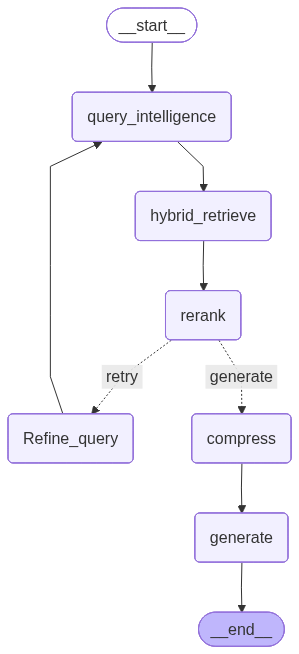

In [120]:
builder = StateGraph(GraphState)

builder.add_node("query_intelligence", query_intelligence_node)
builder.add_node("hybrid_retrieve", hybrid_retrieve_node)
builder.add_node("rerank", rerank_and_filter_node)
builder.add_node("Refine_query", Refine_query_node)
builder.add_node("generate", generate_answer_node)
builder.add_node("compress", compress_documents_node)

builder.set_entry_point("query_intelligence")

builder.add_edge("query_intelligence", "hybrid_retrieve")
builder.add_edge("hybrid_retrieve", "rerank")
builder.add_edge("compress", "generate")


builder.add_conditional_edges(
    "rerank",
    Retry_decision_logic,
    {
        "retry": "Refine_query",
        "generate": "compress"
        # "generate": "generate"
    }
)

builder.add_edge("Refine_query", "query_intelligence")
builder.add_edge("generate", END)

graph = builder.compile()

from IPython.display import Image, display # type: ignore
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Inferencing RAG

In [121]:
result = graph.invoke({
    # "query": "How do we measure faithfulness in computer terminal?"
    "query": "How do we measure faithfulness in RAG?",
    "iteration": 0
})
print(result["answer"])

# compression is changing the docs printed below, ig need to change the prompt for compression

Rewritten_query What are the primary metrics and methodologies employed to assess the faithfulness and groundedness of a Retrieval-Augmented Generation system's output against the provided context?
Expanded_queries ['How is the faithfulness score calculated within the Ragas evaluation framework for RAG pipelines?', 'What are the differences between using Natural Language Inference (NLI) and LLM-as-a-judge to measure factual consistency in RAG?', 'What specific benchmarks and datasets are currently used to evaluate hallucination rates in generative AI systems using retrieval components?']
Step_back_query What are the fundamental principles and standard evaluation components for assessing Retrieval-Augmented Generation systems?
----------------------------
Query:  What are the primary metrics and methodologies employed to assess the faithfulness and groundedness of a Retrieval-Augmented Generation system's output against the provided context?
[Document(metadata={}, page_content='Faithful